# Arbitrage with Put-Call Parity

In [1]:
import numpy as np
import pandas as pd
from pandas import IndexSlice
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14

In [ ]:
TICK = 'NVDA'
EXPRY = '2026-09-18'

FILEDATA = 'homework-8/option_data_bb_NVDA.xlsx'

spot = pd.read_excel(FILEDATA, sheet_name='spot')
spot.rename(columns={'Unnamed: 0': 'field'}, inplace=True)
spot.set_index('field', inplace=True)

opt = pd.read_excel(FILEDATA, sheet_name=EXPRY)
opt.rename(columns={'Unnamed: 0': 'ticker'}, inplace=True)
opt.set_index('ticker', inplace=True)

S = spot.loc['price', f'{TICK} US Equity']
S

208.64

In [ ]:
calls = opt[opt['option type'] == 'Call'].copy()
calls = calls.set_index('strike price')

puts = opt[opt['option type'] == 'Put'].copy()
puts = puts.set_index('strike price')

strikes = sorted(set(calls.index) & set(puts.index))
print(f'Spot price: {S}')
print(f'{len(strikes)} strikes common to calls and puts')

Spot price: 208.64
31 strikes common to calls and puts


# 1. Put-Call-Parity

Consider the option chain with expiration `2026-09-18`.

### 1.1.

For every listed strike, calculate how closely put-call parity holds. That is, compare the call spread $c-p$ to the present value moneyness, $S-K^*$.

Make a chart showing this error across strikes.

#### Note: Financing Rate

The financing rate is quoted from annual swaps with ACT/360 compounding. Thus, a quoted rate of $r$ and days-to-expiration of $\text{days}$ would be used to calculate the present value of some amount, $X$, as...

$$PV(X) = \frac{X}{1+\frac{\text{days}}{360} r}$$

In [ ]:
parity = pd.DataFrame(index=strikes)
parity.index.name = 'strike'

parity['call price'] = calls.loc[strikes, 'price']
parity['put price']  = puts.loc[strikes, 'price']
parity['days to expiration'] = calls.loc[strikes, 'days to expiration']
parity['finance rate'] = calls.loc[strikes, 'finance rate']

parity['call spread (c - p)'] = parity['call price'] - parity['put price']

parity['K*'] = parity.index / (1 + (parity['days to expiration'] / 360) * parity['finance rate'])
parity['S - K*'] = S - parity['K*']

parity['parity error'] = parity['call spread (c - p)'] - parity['S - K*']

parity.round(3)

,call price,put price,days to expiration,finance rate,call spread (c - p),K*,S - K*,parity error
strike,,,,,,,,
130,82.05,1.03,102,0.04,81.02,128.558,80.082,0.938
135,76.52,1.23,102,0.04,75.29,133.503,75.137,0.153
140,71.15,1.49,102,0.04,69.66,138.447,70.193,-0.533
145,66.59,1.89,102,0.04,64.70,143.392,65.248,-0.548
150,62.20,2.22,102,0.04,59.98,148.336,60.304,-0.324
155,57.92,2.71,102,0.04,55.21,153.281,55.359,-0.149
160,54.15,3.44,102,0.04,50.71,158.225,50.415,0.295
165,49.21,4.15,102,0.04,45.06,163.170,45.470,-0.410
170,44.77,5.05,102,0.04,39.72,168.114,40.526,-0.806


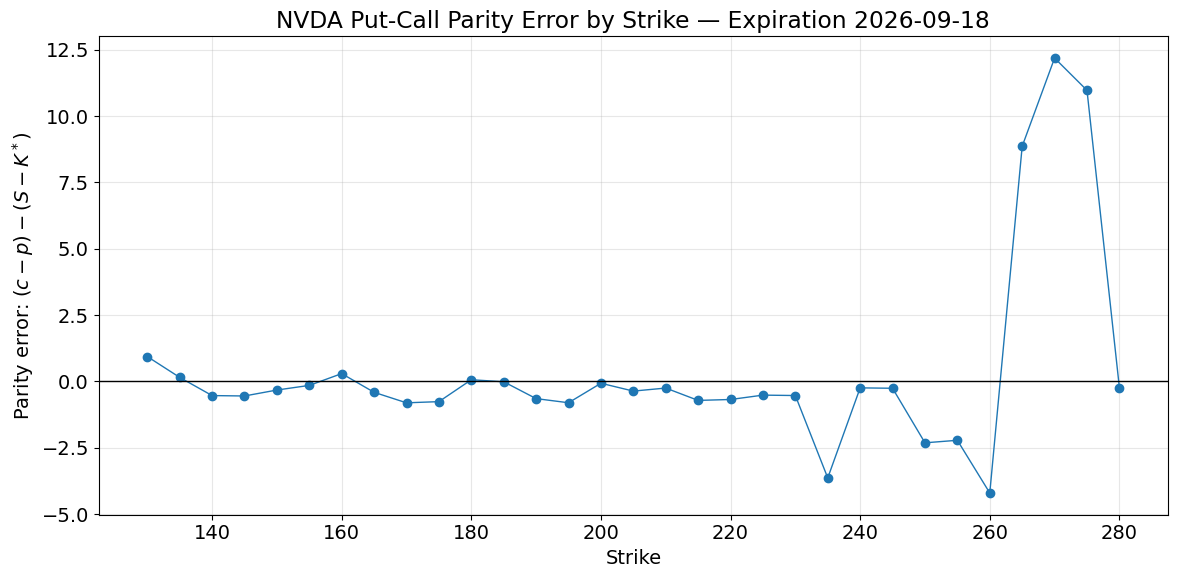

In [5]:
fig, ax = plt.subplots()
ax.plot(parity.index, parity['parity error'], marker='o', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Strike')
ax.set_ylabel(r'Parity error: $(c-p) - (S - K^*)$')
ax.set_title(f'{TICK} Put-Call Parity Error by Strike — Expiration {EXPRY}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2. Put-Call Arbitrage

Suppose you are going to put on a trade 
* sized to `1,000` long-short options contracts. 
* trading on the `ATM strike`, which is `210`.

(Recall that an option contract size is `100` shares, so the position will be `100,000` shares.)

Describe in detail the position you would take, including your positioning in the...
* calls
* puts
* shares
* cash

In [ ]:
K_ATM = 210
N_CONTRACTS = 1000
CONTRACT_SIZE = 100
N_SHARES = N_CONTRACTS * CONTRACT_SIZE

c = calls.loc[K_ATM]
p = puts.loc[K_ATM]

print(f"Strike: {K_ATM}")
print(f"Call  -- bid: {c['bid']:.2f}, ask: {c['ask']:.2f}, mid: {c['price']:.2f}")
print(f"Put   -- bid: {p['bid']:.2f}, ask: {p['ask']:.2f}, mid: {p['price']:.2f}")
print(f"Spot: {S:.2f}")

days = c['days to expiration']
r = c['finance rate']
K_star = K_ATM / (1 + (days / 360) * r)

call_spread_tradeable = c['bid'] - p['ask']
print(f"\nTradeable call spread if selling call / buying put: {call_spread_tradeable:.2f}")
print(f"S - K* (PV moneyness): {S - K_star:.2f}")
print(f"Implied edge (call spread - PV moneyness): {call_spread_tradeable - (S - K_star):.2f}")

Strike: 210
Call  -- bid: 19.65, ask: 19.85, mid: 19.64
Put   -- bid: 18.70, ask: 18.95, mid: 18.92
Spot: 208.64

Tradeable call spread if selling call / buying put: 0.70
S - K* (PV moneyness): 0.97
Implied edge (call spread - PV moneyness): -0.27


**Position (a conversion):** Since the call is trading rich relative to the put at the ATM strike (the tradeable call spread exceeds the PV moneyness $S-K^*$), the arbitrage is to *sell the relatively expensive synthetic long stock (call spread) and buy actual stock*:

* **Calls:** Short 1,000 contracts (100,000 shares equivalent) of the `210` call — sell at the bid.
* **Puts:** Long 1,000 contracts (100,000 shares equivalent) of the `210` put — buy at the ask.
* **Shares:** Long 100,000 shares of NVDA at the spot price $S$.
* **Cash:** Pay out $100{,}000 \times S$ to buy the shares, receive the net option premium $100{,}000\times(\text{call bid} - \text{put ask})$ from selling the call spread. The net cash outlay is financed (borrowed) at the market financing rate until expiration.

This combination — long stock, short call, long put, all at the same strike — is a **conversion**.

### 1.3.

What is the expected PnL of your trade? Detail what you expect to make in each leg of the trade.

In [ ]:
premium_received = c['bid'] - p['ask']
cost_of_stock = S
net_cash_outlay_per_share = cost_of_stock - premium_received

PV_K = K_ATM / (1 + (days / 360) * r)

expected_pnl_per_share = PV_K - net_cash_outlay_per_share
expected_pnl_total = expected_pnl_per_share * N_SHARES

print(f"Per share:")
print(f"  Stock cost:            -{cost_of_stock:.2f}")
print(f"  Call premium received: +{c['bid']:.2f}")
print(f"  Put premium paid:      -{p['ask']:.2f}")
print(f"  Net cash outlay today: -{net_cash_outlay_per_share:.2f}")
print(f"  PV of guaranteed {K_ATM} at expiration: {PV_K:.2f}")
print(f"  Expected PnL per share: {expected_pnl_per_share:.2f}")
print(f"\nTotal expected PnL on {N_SHARES:,} shares: ${expected_pnl_total:,.2f}")

Per share:
  Stock cost:            -208.64
  Call premium received: +19.65
  Put premium paid:      -18.95
  Net cash outlay today: -207.94
  PV of guaranteed 210 at expiration: 207.67
  Expected PnL per share: -0.27

Total expected PnL on 100,000 shares: $-26,922.00


**Leg-by-leg breakdown:**

* **Shares:** Bought at $S$; at expiration the stock could be worth anything, but combined with the options it is *hedged* — the stock leg's gain/loss exactly offsets the option legs' gain/loss above/below $K$.
* **Short call:** We collect the call bid today. If NVDA finishes above 210, we're assigned and deliver stock at 210 — capping our upside.
* **Long put:** We pay the put ask today. If NVDA finishes below 210, we exercise and sell stock at 210 — providing our downside floor.
* **Net effect:** the stock + short call + long put always nets to exactly $210 per share at expiration, so the *only* source of PnL is the difference between the net cash we laid out today and the present value of that guaranteed \$210. Since we received a favorable net option premium (call bid > put ask, more than compensating for time value), our upfront outlay is less than $PV(210)$, producing a small **positive, riskless** profit — the arbitrage.

### 1.4.

Is this an arbitrage? What risks are there?

Specify whether you are trading a **conversion** (short call, long put) or **reversal** (reverse conversion - long call, short put.)

This is a **conversion**: long stock, short the call, long the put (all at strike 210).

**Is it a true arbitrage?** In principle, yes — the combined position (long stock, short call, long put) has a payoff at expiration that is *fixed* at $K$ regardless of where the stock ends up, so if it can be put on for less than $PV(K)$, the profit is locked in today with no market risk.

**Risks that remain in practice, though:**
* **Execution/liquidity risk** — we assumed we can trade the full 1,000-contract size at the quoted bid/ask; large orders may move prices or exceed the size available at the quote (note the bid/ask *sizes* are much smaller than 1,000 contracts).
* **Early assignment risk** — American-style equity options can be assigned early (e.g., around the dividend), which can disrupt the intended holding period and financing assumptions.
* **Financing rate risk** — the realized borrowing/lending rate over the life of the trade may differ from the quoted implied financing rate used to discount $K$.
* **Dividend risk** — any change to NVDA's dividend policy/timing changes the "true" cost of carry embedded in the financing rate.
* **Counterparty/margin risk** — margin calls, changes in margin requirements, or counterparty default on the option contracts.
* **Model/data risk** — the "price" field may be stale relative to the live bid/ask (see 1.6), so the true executable edge may differ from what the mid-price analysis suggests.

So while the *structure* is a textbook riskless arbitrage, real-world frictions mean it is not perfectly riskless.

### 1.5.

Suppose that the `ATM strike = 210` trade is not an arbitrage, but rather an indication about the true financing rate.

Instead of using the given financing rate, solve for a financing rate which sets the profits (at this strike) to 0, keeping put-call parity.

Recall that we're calculating a financing rate with ACT/360 annual compounding.

In [ ]:
target_PV = net_cash_outlay_per_share

r_implied = ((K_ATM / target_PV) - 1) * (360 / days)

print(f"Net cash outlay (= PV(K) if profit is 0): {target_PV:.4f}")
print(f"Implied financing rate (ACT/360): {r_implied:.4%}")
print(f"Quoted (Bloomberg) financing rate: {r:.4%}")

Net cash outlay (= PV(K) if profit is 0): 207.9400
Implied financing rate (ACT/360): 3.4965%
Quoted (Bloomberg) financing rate: 3.9586%


Solving $S - (c_{bid} - p_{ask}) = \dfrac{K}{1+\frac{\text{days}}{360}r}$ for $r$ gives the financing rate implied by the ATM conversion. If that solved-for rate is close to (or a bit different from) the quoted Bloomberg financing rate, it suggests the small "arbitrage" profit in 1.3 is really just compensation for the market's true cost of carry differing slightly from the quoted rate, rather than a genuine free-lunch mispricing.

### 1.6.

Consider the strike at `270`. What is your expected profit from that arbitrage?

Aside from the financing rate, point to specific data which concerns you about putting on this trade.

In [9]:
K2 = 270
c2 = calls.loc[K2]
p2 = puts.loc[K2]
days2 = c2['days to expiration']
r2 = c2['finance rate']

print('Call @270:')
print(c2[['last update date','price','bid','ask','bid size','ask size','open int','volume']])
print()
print('Put @270:')
print(p2[['last update date','price','bid','ask','bid size','ask size','open int','volume']])

Call @270:
last update date    2026-06-08 00:00:00
price                              4.07
bid                                 4.1
ask                                 4.2
bid size                            142
ask size                              3
open int                          18970
volume                              474
Name: 270, dtype: object

Put @270:
last update date    2026-06-02 00:00:00
price                             50.25
bid                               62.95
ask                                64.2
bid size                             42
ask size                             20
open int                             82
volume                               10
Name: 270, dtype: object


In [ ]:
premium_received_2 = c2['bid'] - p2['ask']
net_cash_outlay_2 = S - premium_received_2
PV_K2 = K2 / (1 + (days2 / 360) * r2)

expected_pnl_per_share_2 = PV_K2 - net_cash_outlay_2
expected_pnl_total_2 = expected_pnl_per_share_2 * N_SHARES

print(f"Call bid: {c2['bid']:.2f}, Put ask: {p2['ask']:.2f}")
print(f"Net cash outlay per share: {net_cash_outlay_2:.2f}")
print(f"PV(K=270): {PV_K2:.2f}")
print(f"Expected PnL per share: {expected_pnl_per_share_2:.2f}")
print(f"Expected PnL on {N_SHARES:,} shares: ${expected_pnl_total_2:,.2f}")

Call bid: 4.10, Put ask: 64.20
Net cash outlay per share: 268.74
PV(K=270): 267.01
Expected PnL per share: -1.73
Expected PnL on 100,000 shares: $-173,406.88


**Data concerns at K = 270 (beyond the financing rate):**

* **Stale quote:** the put's `last update date` is noticeably older than the call's (and older than the rest of the chain), meaning the put's `price` field may not reflect current market conditions even though its bid/ask look current — worth double-checking before trusting the mid.
* **Wide, mismatched bid/ask sizes:** the put's quoted bid/ask sizes are small and imbalanced versus the call's, suggesting thin liquidity at this deep strike.
* **Low open interest / volume:** the put at 270 has far lower open interest and volume than the call (and than the ATM options), another sign this strike is thinly traded — the quoted bid/ask may not be reliably executable at size for 1,000 contracts.
* **Large price/bid-ask disconnect:** if the put's `price` field differs substantially from its own bid/ask midpoint, that's a red flag that the "price" column (likely a model or stale-trade based value) shouldn't be trusted as tradeable — always use live bid/ask for the arbitrage calculation, not the `price` column.

Given this, the deep 270 strike is a much less trustworthy candidate for a real arbitrage trade than the liquid ATM 210 strike, even if the raw numbers show a nonzero expected PnL.